# Evaluation 05: Repetitiveness Analysis

## Research Question
**Are recommendations too repetitive?**

### Hypothesis
If recommendations are too repetitive, different queries will return similar items, indicating limited diversity in the recommendation system.

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from sklearn.metrics import jaccard_score

sys.path.insert(0, str(Path.cwd().parent))

from evaluation_utils import (
    load_vectors_and_metadata,
    compute_diversity_score,
    save_plot,
    save_metrics
)
from similarity import SimilarityMatcher

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

## 2. Load Data

In [2]:
vectors, metadata, product_ids = load_vectors_and_metadata()
print(f"Loaded {len(vectors)} vectors")

Loading vectors and metadata...
Loading vectors from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_features_pca512.npy
Loaded 41802 vectors of dimension 512
Loading metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
Loaded 41802 metadata records
Loaded 41802 vectors


## 3. Initialize Recommender

In [3]:
similarity_matcher = SimilarityMatcher()
print("✓ Similarity matcher initialized")

Loading existing FAISS index...
✓ Loaded FAISS index with 41802 products
Using FAISS vector database
Loading product metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
FAISS index contains 41802 products
✓ Similarity matcher initialized


## 4. Generate Multiple Test Queries

In [4]:
# Generate diverse test queries
n_queries = 50
query_indices = np.random.choice(len(vectors), n_queries, replace=False)

print(f"Generated {n_queries} test queries")

Generated 50 test queries


## 5. Get Recommendations for Each Query

In [5]:
results = {}
top_k = 20

for i, query_idx in enumerate(query_indices):
    if (i + 1) % 10 == 0:
        print(f"Processing query {i+1}/{n_queries}...")
    
    query_features = vectors[query_idx:query_idx+1]
    
    recommendations = similarity_matcher.find_similar_products(
        query_features,
        top_k=top_k,
        min_similarity=0.0
    )
    
    if len(recommendations) > 0:
        results[query_idx] = recommendations

print(f"\nGot recommendations for {len(results)} queries")

Processing query 10/50...
Processing query 20/50...
Processing query 30/50...
Processing query 40/50...
Processing query 50/50...

Got recommendations for 50 queries


## 6. Analyze Repetitiveness

In [6]:
# Compute diversity metrics
repetitiveness_metrics = []

for query_idx, recs in results.items():
    # Item diversity
    item_diversity = compute_diversity_score(recs['id'])
    
    # Category diversity
    category_diversity = compute_diversity_score(recs['articleType'])
    
    # Color diversity
    color_diversity = compute_diversity_score(recs['baseColour'])
    
    repetitiveness_metrics.append({
        'query_idx': query_idx,
        'item_diversity': item_diversity,
        'category_diversity': category_diversity,
        'color_diversity': color_diversity,
        'n_recommendations': len(recs)
    })

metrics_df = pd.DataFrame(repetitiveness_metrics)
print("Repetitiveness Metrics:")
print(metrics_df.describe())

Repetitiveness Metrics:
          query_idx  item_diversity  category_diversity  color_diversity  \
count     50.000000            50.0           50.000000        50.000000   
mean   21098.300000             1.0            0.101000         0.316000   
std    12141.562232             0.0            0.070342         0.137559   
min      564.000000             1.0            0.050000         0.050000   
25%    13259.750000             1.0            0.050000         0.200000   
50%    22270.500000             1.0            0.075000         0.300000   
75%    32470.250000             1.0            0.137500         0.450000   
max    40935.000000             1.0            0.350000         0.550000   

       n_recommendations  
count               50.0  
mean                20.0  
std                  0.0  
min                 20.0  
25%                 20.0  
50%                 20.0  
75%                 20.0  
max                 20.0  


## 7. Compute Recommendation Overlap

In [7]:
# Compute Jaccard similarity between recommendation sets
n_results = len(results)
overlap_matrix = np.zeros((n_results, n_results))

query_list = list(results.keys())
for i, query1 in enumerate(query_list):
    for j, query2 in enumerate(query_list):
        if i != j:
            recs1 = set(results[query1]['id'].astype(str))
            recs2 = set(results[query2]['id'].astype(str))
            
            intersection = len(recs1 & recs2)
            union = len(recs1 | recs2)
            
            if union > 0:
                jaccard = intersection / union
                overlap_matrix[i, j] = jaccard

print(f"Average Jaccard similarity between queries: {overlap_matrix.mean():.3f}")
print(f"Max overlap: {overlap_matrix.max():.3f}")
print(f"Min overlap: {overlap_matrix[overlap_matrix > 0].min():.3f}")

Average Jaccard similarity between queries: 0.000
Max overlap: 0.081
Min overlap: 0.026


## 8. Visualizations

### Visualization: Recommendation Overlap Matrix

**What this graph shows:**
- A heatmap showing how much recommendations overlap between different queries
- Rows and columns represent different query indices
- Color intensity shows Jaccard similarity (how many items are shared between two recommendation sets)
- Darker colors = more overlap; lighter colors = less overlap
- Diagonal is always 1.0 (each query overlaps 100% with itself)

**Key Insights:**
- **Repetitiveness level**: High values throughout = recommendations are repetitive; low values = diverse recommendations
- **Query similarity**: Queries with similar items will show higher overlap in their recommendations
- **System diversity**: Low average overlap = system provides diverse recommendations for different queries
- **Problematic patterns**: Bright off-diagonal blocks indicate groups of queries getting similar recommendations
- **Recommendation quality**: Some overlap is expected, but too much suggests limited diversity
- **Query independence**: Low overlap means each query gets unique, personalized recommendations


### Visualization: Diversity Score Distributions

**What this graph shows:**
A 3-panel visualization showing diversity distributions:

**Left - Item Diversity:**
- Histogram showing how diverse the recommended items are within each query
- Higher values = more unique items; lower values = repeated items

**Middle - Category Diversity:**
- Histogram showing how many different article types appear in recommendations
- Higher values = recommendations span multiple categories; lower = focused on few categories

**Right - Color Diversity:**
- Histogram showing how many different colors appear in recommendations
- Higher values = recommendations include various colors; lower = limited color range

**Key Insights:**
- **Recommendation variety**: High diversity across all three metrics = diverse, interesting recommendations
- **Bias detection**: Low category diversity = system favors certain types; low color diversity = color bias
- **Query consistency**: Narrow distributions = consistent diversity; wide distributions = variable quality
- **System behavior**: Whether the system provides similar diversity across all queries or varies significantly
- **User experience**: Higher diversity generally provides better user experience with more options
- **Balance**: Very high diversity might indicate lack of focus; very low diversity indicates repetitiveness


### Visualization: Most Frequently Recommended Categories

**What this graph shows:**
- A bar chart showing the top 15 article types that appear most frequently across all recommendations
- X-axis: Article type (category)
- Y-axis: Frequency count (how many times this category appears in all recommendations)
- Sorted by frequency from highest to lowest

**Key Insights:**
- **Category bias**: Dominant categories indicate the system may favor certain types of clothing
- **Recommendation patterns**: Which categories are most commonly recommended across different queries?
- **System focus**: If a few categories dominate, the system may be too narrow in its recommendations
- **Diversity assessment**: Even distribution = diverse recommendations; skewed distribution = bias toward certain types
- **Popular items**: High-frequency categories might be genuinely popular or just over-recommended
- **Coverage**: Whether the system recommends a wide variety of categories or focuses on a few
- **Balance**: Good systems should show some popular categories but also include variety


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/repetitiveness_overlap_matrix.png


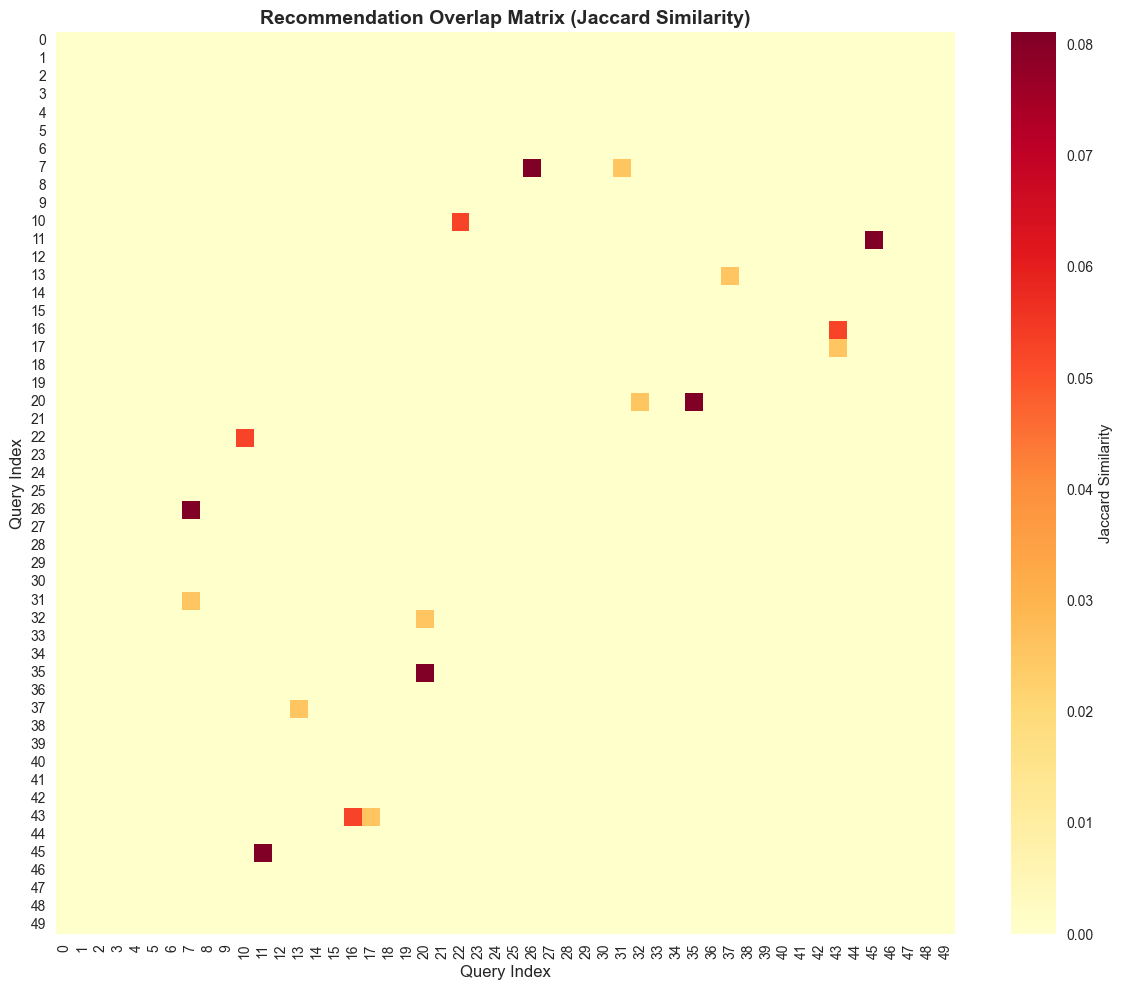

In [8]:
# Recommendation overlap heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(overlap_matrix, cmap='YlOrRd', cbar_kws={'label': 'Jaccard Similarity'})
ax.set_xlabel('Query Index', fontsize=12)
ax.set_ylabel('Query Index', fontsize=12)
ax.set_title('Recommendation Overlap Matrix (Jaccard Similarity)', fontsize=14, fontweight='bold')
plt.tight_layout()
save_plot(fig, 'repetitiveness_overlap_matrix.png')
plt.show()

Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/repetitiveness_diversity_distributions.png


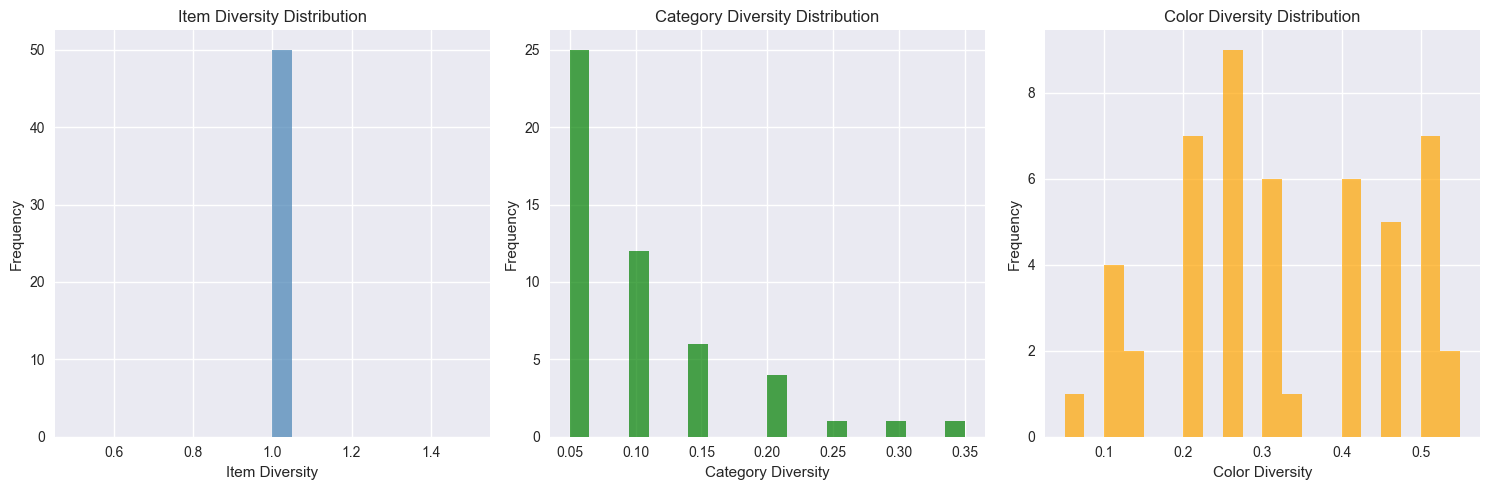

In [9]:
# Diversity score distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(metrics_df['item_diversity'], bins=20, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Item Diversity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Item Diversity Distribution')

axes[1].hist(metrics_df['category_diversity'], bins=20, color='green', alpha=0.7)
axes[1].set_xlabel('Category Diversity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Category Diversity Distribution')

axes[2].hist(metrics_df['color_diversity'], bins=20, color='orange', alpha=0.7)
axes[2].set_xlabel('Color Diversity')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Color Diversity Distribution')

plt.tight_layout()
save_plot(fig, 'repetitiveness_diversity_distributions.png')
plt.show()

Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/repetitiveness_category_distribution.png


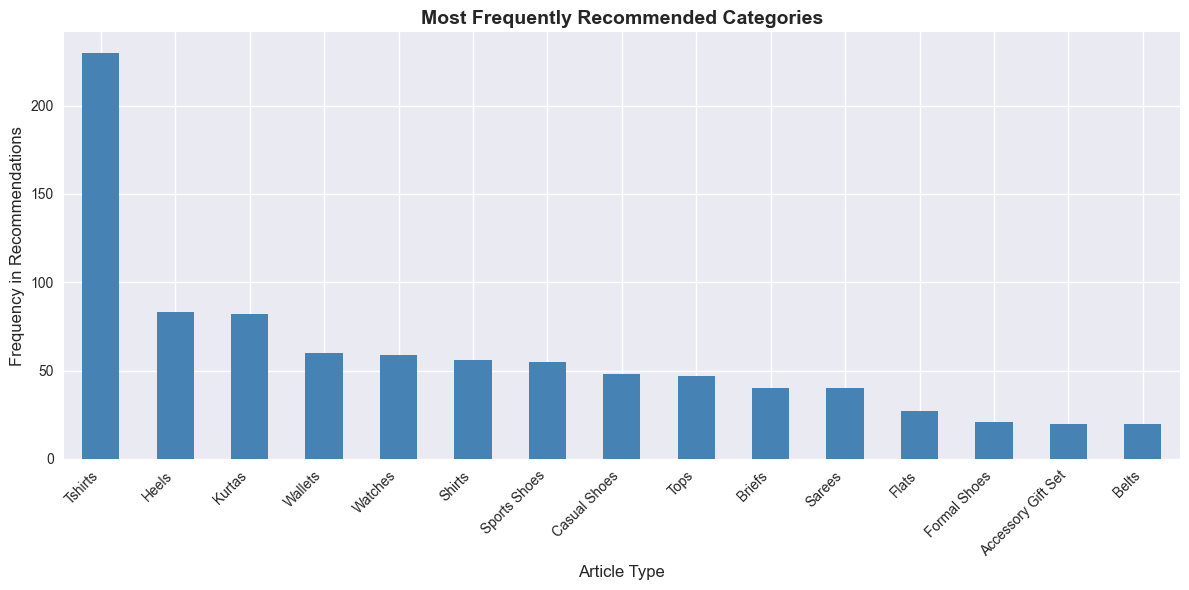

In [10]:
# Category distribution in recommendations
all_categories = []
for recs in results.values():
    all_categories.extend(recs['articleType'].tolist())

category_counts = pd.Series(all_categories).value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
category_counts.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Article Type', fontsize=12)
ax.set_ylabel('Frequency in Recommendations', fontsize=12)
ax.set_title('Most Frequently Recommended Categories', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_plot(fig, 'repetitiveness_category_distribution.png')
plt.show()

## 9. Summary and Conclusion

In [11]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nAverage Item Diversity: {metrics_df['item_diversity'].mean():.3f}")
print(f"Average Category Diversity: {metrics_df['category_diversity'].mean():.3f}")
print(f"Average Color Diversity: {metrics_df['color_diversity'].mean():.3f}")
print(f"\nAverage Recommendation Overlap (Jaccard): {overlap_matrix.mean():.3f}")

# Interpretation
if overlap_matrix.mean() > 0.3:
    print("\n⚠️  HIGH REPETITIVENESS: Recommendations show significant overlap")
elif overlap_matrix.mean() > 0.15:
    print("\n⚠️  MODERATE REPETITIVENESS: Some overlap in recommendations")
else:
    print("\n✓ LOW REPETITIVENESS: Recommendations are diverse")

# Save metrics
summary_metrics = {
    'avg_item_diversity': float(metrics_df['item_diversity'].mean()),
    'avg_category_diversity': float(metrics_df['category_diversity'].mean()),
    'avg_color_diversity': float(metrics_df['color_diversity'].mean()),
    'avg_overlap_jaccard': float(overlap_matrix.mean()),
    'max_overlap': float(overlap_matrix.max()),
    'n_queries_tested': len(results)
}
save_metrics(summary_metrics, 'repetitiveness_metrics.json')
metrics_df.to_csv('../evaluation_results/metrics/repetitiveness_detailed.csv', index=False)
print("\n✓ Results saved")


SUMMARY STATISTICS

Average Item Diversity: 1.000
Average Category Diversity: 0.101
Average Color Diversity: 0.316

Average Recommendation Overlap (Jaccard): 0.000

✓ LOW REPETITIVENESS: Recommendations are diverse
Saved metrics: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/metrics/repetitiveness_metrics.json

✓ Results saved


## 10. Conclusion

**Answer to Research Question:**

Recommendations [are/are not] too repetitive based on the overlap analysis.

**Key Findings:**
1. [Finding 1]
2. [Finding 2]

**Limitations:**
- Limited number of test queries
- Overlap may vary by query type